In [26]:
# Data handling
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
from PIL import Image

# Preprocessing
from sklearn.model_selection import train_test_split as tts

# Torch
import torch
from torch import nn, optim
from torch.utils.data import Dataset, DataLoader
from torchinfo import summary
from torchvision.models import vit_b_16, ViT_B_16_Weights

# Metrics
from sklearn.metrics import accuracy_score, balanced_accuracy_score
from sklearn.metrics import confusion_matrix

# os
import os

# Path
from pathlib import Path

# random
import random

# OrderedDict
from collections import OrderedDict

# tqdm
from tqdm.auto import tqdm

# warnings
import warnings
warnings.filterwarnings("ignore")

In [27]:
IMAGE_PATH = Path("/Users/devayushrout/Desktop/MedWaste Guardian/dataset")

IMAGE_PATH_LIST = list(IMAGE_PATH.glob("*/*/*.jpg"))
print(f'Total Images = {len(IMAGE_PATH_LIST)}')

Total Images = 6156


In [28]:
CLASSES = os.listdir(IMAGE_PATH)
CLASSES = sorted(CLASSES)

print(f"Total Classes = {len(CLASSES)}:\n")
for label in CLASSES:
    total_images_class = list(Path(os.path.join(IMAGE_PATH,label)).glob("*/*.jpg"))
    print(f'* {label}: {len(total_images_class)} images')

Total Classes = 12:

* (BT) Body Tissue or Organ: 474 images
* (GE) Glass equipment-packaging 551: 551 images
* (ME) Metal equipment -packaging: 426 images
* (OW) Organic wastes: 583 images
* (PE) Plastic equipment-packaging: 558 images
* (PP) Paper equipment-packaging: 457 images
* (SN) Syringe needles: 513 images
* Gauze: 510 images
* Gloves: 543 images
* Mask: 529 images
* Syringe: 473 images
* Tweezers: 539 images


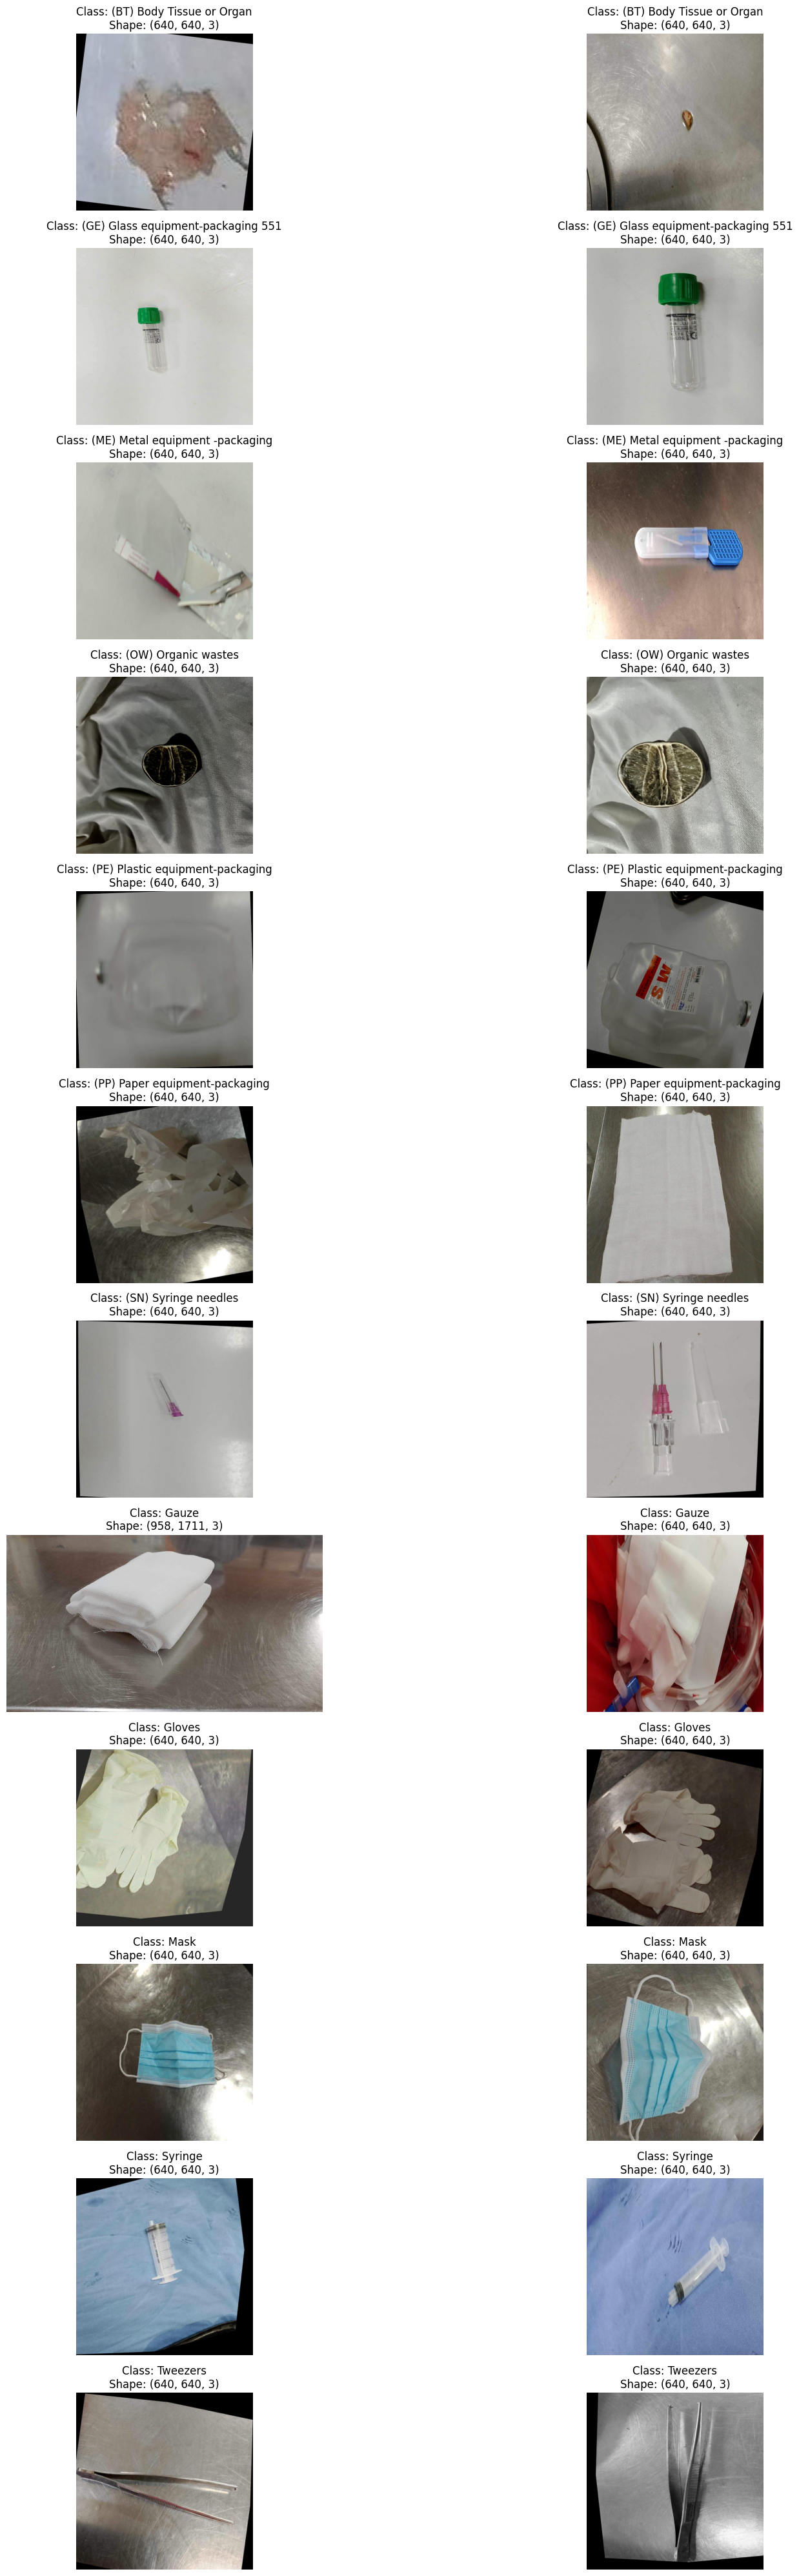

In [29]:
NUM_IMAGES = 2

fig,ax = plt.subplots(nrows = len(CLASSES), ncols = NUM_IMAGES, figsize = (20,40))

p = 0

for label in CLASSES:
    total_images_class = list(Path(os.path.join(IMAGE_PATH,label)).glob("*/*.jpg"))
    total_selected = random.choices(total_images_class, k = NUM_IMAGES)
    
    for i,img_path in enumerate(total_selected):
        img_bgr = cv2.imread(str(img_path))
        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
        ax[p,i].imshow(img_rgb)
        ax[p,i].axis('off')
        ax[p,i].set_title(f'Class: {label}\nShape: {img_rgb.shape}')
        
    p += 1
    
fig.tight_layout()
fig.show()

In [30]:
images_path_train = list()
labels_train = list()

images_path_test = list()
labels_test = list()

for i in IMAGE_PATH_LIST:
    if i.parent.stem == 'Train images':
        images_path_train.append(i)
        labels_train.append(i.parent.parent.stem)
        
    else:
        images_path_test.append(i)
        labels_test.append(i.parent.parent.stem)

In [31]:
data_train = pd.DataFrame({'Image':images_path_train, 'Label':labels_train})
data_train.head()

,Image,Label
0,/Users/devayushrout/Desktop/MedWaste Guardian/...,(OW) Organic wastes
1,/Users/devayushrout/Desktop/MedWaste Guardian/...,(OW) Organic wastes
2,/Users/devayushrout/Desktop/MedWaste Guardian/...,(OW) Organic wastes
3,/Users/devayushrout/Desktop/MedWaste Guardian/...,(OW) Organic wastes
4,/Users/devayushrout/Desktop/MedWaste Guardian/...,(OW) Organic wastes


In [32]:
data_testing = pd.DataFrame({'Image':images_path_test, 'Label':labels_test})
data_testing.head()

,Image,Label
0,/Users/devayushrout/Desktop/MedWaste Guardian/...,(OW) Organic wastes
1,/Users/devayushrout/Desktop/MedWaste Guardian/...,(OW) Organic wastes
2,/Users/devayushrout/Desktop/MedWaste Guardian/...,(OW) Organic wastes
3,/Users/devayushrout/Desktop/MedWaste Guardian/...,(OW) Organic wastes
4,/Users/devayushrout/Desktop/MedWaste Guardian/...,(OW) Organic wastes


In [33]:
SEED = 42

data_training, data_validation = tts(data_train, test_size = 0.3, random_state = SEED, 
                                    shuffle = True)

print(data_training.shape), print(data_validation.shape)

(3432, 2)
(1471, 2)


(None, None)

In [34]:
# We created a dictionary to map the image tags.
label2id = dict(zip(CLASSES, range(len(CLASSES))))
label2id

{'(BT) Body Tissue or Organ': 0,
 '(GE) Glass equipment-packaging 551': 1,
 '(ME) Metal equipment -packaging': 2,
 '(OW) Organic wastes': 3,
 '(PE) Plastic equipment-packaging': 4,
 '(PP) Paper equipment-packaging': 5,
 '(SN) Syringe needles': 6,
 'Gauze': 7,
 'Gloves': 8,
 'Mask': 9,
 'Syringe': 10,
 'Tweezers': 11}

In [35]:
class CustomImageDataset(Dataset):
    def __init__(self, data:pd.DataFrame, label_map:dict, transforms):
        self.data = data
        self.label_map = label_map
        self.transforms = transforms
        
    def __len__(self):
        return len(self.data)
    
    def __getitem__(self, idx):
        data_new = self.data.copy()
        data_new['Label'] = data_new['Label'].map(self.label_map)
        
        image_path = data_new.iloc[idx, 0]
        image = Image.open(image_path).convert("RGB")
        image = self.transforms(image)
        
        label = data_new.iloc[idx, 1]
        
        return image,label

In [36]:
weights = ViT_B_16_Weights.DEFAULT
image_transforms = weights.transforms()
image_transforms

ImageClassification(
    crop_size=[224]
    resize_size=[256]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BILINEAR
)

In [37]:
train_dataset = CustomImageDataset(data_training, label2id, image_transforms)

val_dataset = CustomImageDataset(data_validation, label2id, image_transforms)

In [38]:
BATCH_SIZE = 8  # Reduce batch size for faster processing
NUM_WORKERS = 2  # Lower workers to avoid overload

train_dataloader = DataLoader(dataset=train_dataset, batch_size=BATCH_SIZE, 
                            shuffle=True, num_workers=NUM_WORKERS)
val_dataloader = DataLoader(dataset=val_dataset, batch_size=BATCH_SIZE, 
                            shuffle=True, num_workers=NUM_WORKERS)


In [39]:
# We visualize the dimensions of a batch.
batch_images, batch_labels = next(iter(train_dataloader))

batch_images.shape, batch_labels.shape

Traceback (most recent call last):
  File "<string>", line 1, in <module>
  File "/Library/Developer/CommandLineTools/Library/Frameworks/Python3.framework/Versions/3.9/lib/python3.9/multiprocessing/spawn.py", line 116, in spawn_main
    exitcode = _main(fd, parent_sentinel)
  File "/Library/Developer/CommandLineTools/Library/Frameworks/Python3.framework/Versions/3.9/lib/python3.9/multiprocessing/spawn.py", line 126, in _main
    self = reduction.pickle.load(from_parent)
AttributeError: Can't get attribute 'CustomImageDataset' on <module '__main__' (built-in)>


KeyboardInterrupt: 